# 🌊 Make Continuum Static Maps 
<br>
<img style="float: left; padding-right: 15px; padding-left: 0px;" src="../sources/images/logo_continuum.png" width="260px" align=”left” >

<div style="text-align: justify">
This notebook loads parameters from a configuration file (`config.json`), saved in the `settings` folder and do a set of operations for the preparations of the static land data for Continuum model:

- performs Digital Elevation Model (DEM) preprocessing
- hydrological condition the DEM with provided spatial datasets
- compute the key hydrological derivatives
- provide the full set of hydrological model land data

The entire workflow is documented with clear explanations and visual plots to help the user to understand each step.

## 🔧 Preliminary Setup

This section handles the initial configuration, including setting the project file, importing necessary libraries, and preparing the working environment.

#### Specify Configuration File

This cell defines the name of the configuration file to be used for the entire workflow. The configuration file, `awash.yaml` in this case, contains all the parameters for the project.

In [1]:
# Set the name of the settings file
settings_file = "awashOmbole_static.json"

print(f"Using settings file: {settings_file}")

Using settings file: awashOmbole_static.json


#### Import Required Libraries

This cell imports all the Python libraries necessary to run the notebook. These libraries cover a wide range of functionalities, including data handling (`json`, `os`, `pathlib`, `numpy`), geospatial operations (`rasterio`, `geopandas`, `pygrass`), plotting (`matplotlib`), and custom tools from local modules.

In [2]:
import json
import os
from pathlib import Path

import os, math, time, logging, shutil, subprocess
import numpy as np
import math
import pandas as pd
import rasterio as rio
import geopandas as gpd
import matplotlib.pyplot as plt
from grass_session import Session
from grass.pygrass.modules.shortcuts import general as g, raster as r, vector as v
from grass.pygrass.modules import Module
from grass.script import parse_key_val
import grass.script as gs
from subprocess import PIPE
from rasterio import Affine, features
from copy import deepcopy
from osgeo import gdal, gdalconst


import geo_tools, plot_tools, io_tools, hmc_tools

from IPython.display import display, clear_output
%matplotlib ipympl

plt.close('all')
print("All required libraries have been imported.")

All required libraries have been imported.


#### Set Up Working Paths and Generate Folder Structure

This cell sets the project's root directory and loads the configuration from the specified YAML file. It then uses the `path` settings from the configuration to create the necessary folder structure for the project if it doesn't already exist.

In [3]:
# Define the project root directory
project_root = str(Path().cwd()).replace('notebook_continuum','')

# Load configuration from the JSON file
with open(os.path.join(project_root, "settings", settings_file), 'r') as f:
    config = json.load(f)
    
print(f"Configuration loaded from settings file: {settings_file}")

# Generate folder tree based on the configuration
path_settings = config['path']
for key in path_settings.keys():
    path_settings[key] = os.path.join(project_root, "projects", config['general']['project'], path_settings[key])
    os.makedirs(path_settings[key], exist_ok=True)
    
print("Folder tree generated successfully.")
print(f"Project root: {project_root}")

Configuration loaded from settings file: awashOmbole_static.json
Folder tree generated successfully.
Project root: /home/continuumuser/workdir/


## 🛑 **WARNING! Copy all required data to the `data` folder before proceeding** 🛑
In particular the DEM and, if present, rivers, depression and walls

---

## ⛰️ DEM Preprocessing

This section focuses on preparing the Digital Elevation Model (DEM) for hydrological analysis. This involves reading the original DEM, resampling its resolution if needed, and filling sinks.

#### Read Input Digital Elevation Model

This cell reads the original DEM file specified in the configuration. It handles nodata values, replacing them with `NaN` for proper numerical operations. The cell then calculates and prints the DEM's resolution and plots the original DEM for visual inspection.

In [5]:
# Open the original DEM file
with rio.open(os.path.join(path_settings['data'], config['data']['dem'])) as src:
    dem_orig = src.read(1)
    tr = src.transform
    profile = src.profile
    nod = src.nodata if src.nodata is not None else -9999
    dem_orig[dem_orig==nod] = np.nan
    
print("Original DEM read successfully.")
print(f"DEM dimensions: {dem_orig.shape}")
    
# Plot the original DEM
# plot_tools.single_plot(dem_orig, "Original DEM", cmap='terrain')

# Calculate and print the resolution of the input DEM
working_res_km = geo_tools.deg2km((np.abs(tr[0]) + np.abs(tr[4])) / 2)
print(f"DEM imported correctly! Input DEM resolution is around {working_res_km:.3f} km.")

Original DEM read successfully.
DEM dimensions: (6171, 7375)
DEM imported correctly! Input DEM resolution is around 0.093 km.


#### Resample DEM Resolution

This cell checks a flag in the configuration to determine if the DEM needs to be resampled to a different resolution. If the flag is set to `True`, it resamples the DEM to the specified output resolution with cubic interpolation, saves the new DEM, and plots it for comparison. Otherwise, it uses the original DEM.

Resampling DEM to 1 km resolution...
Resampling complete. Plotting resampled DEM...


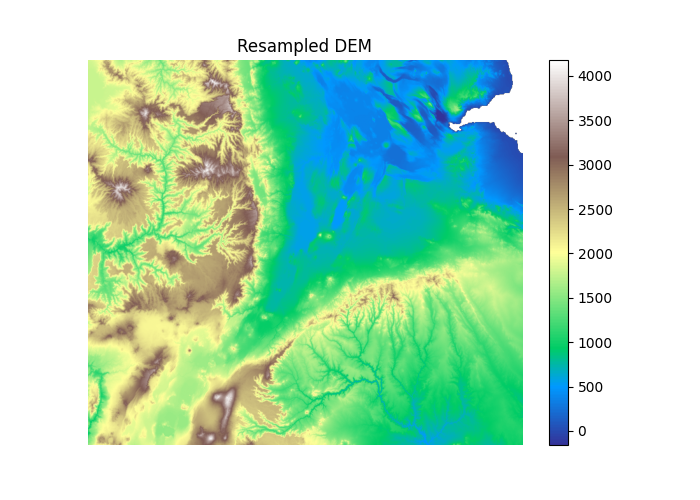

In [6]:
# Check if DEM resampling is required
if config['flags']['change_dem_resolution']:
    if config['settings']['out_res_km'] is None:
        raise ValueError("Please provide a numerical value for out_res_km in the configuration.")
        
    working_res_km = config['settings']['out_res_km']
    print(f"Resampling DEM to {working_res_km} km resolution...")
    
    # Resample the DEM
    dem_file_raw, profile = geo_tools.resample(out = os.path.join(path_settings['ancillary'], "dem_resampled.tif"),
                                  inp = os.path.join(path_settings['data'], config['data']['dem']),
                                  target_res_deg = geo_tools.km2deg(working_res_km))
                                  
    print("Resampling complete. Plotting resampled DEM...")
    
    # Read and plot the resampled DEM
    with rio.open(os.path.join(path_settings['ancillary'], "dem_resampled.tif")) as src:
        dem_working = src.read(1)
        tr = src.transform
        nod = src.nodata if src.nodata is not None else -9999
        dem_working[dem_working==nod] = np.nan
    
    plot_tools.single_plot(dem_working, "Resampled DEM", cmap='terrain')
else:
    print("No resampling of the original DEM required.")
    dem_working = dem_orig
    dem_file_raw = os.path.join(path_settings['data'], config['data']['dem'])

#### Fill Sinks with SAGA GIS

This cell uses SAGA GIS via command-line calls to process the DEM. It first identifies and fills sinks, which are low points in the DEM that trap water flow. This step is crucial for accurate hydrological analysis. The temporary SAGA files are deleted afterward.

In [7]:
%matplotlib ipympl
# Define file paths for SAGA GIS processing
saga_dem = os.path.join(path_settings['ancillary'], "dem_saga.sdat")
sink_route = os.path.join(path_settings['ancillary'], "sinkroute_saga.sdat")
dem_file_processed = os.path.join(path_settings['ancillary'], "dem_preprocessed.tif")

print("Starting DEM sink-filling process using SAGA GIS.")

# Import DEM to SAGA format
display("Step 1/4: Importing DEM to SAGA format...")
os.system(f"gdal_translate -q -of SAGA {dem_file_raw} {saga_dem}")

# Identify sink routes
display("Step 2/4: Identifying sink routes...")
os.system(f"saga_cmd -f=s ta_preprocessor 1 -ELEVATION {saga_dem} -SINKROUTE {sink_route}")

# Fill sinks
display("Step 3/4: Filling sinks...")
os.system(f"saga_cmd -f=s ta_preprocessor 2 -DEM {saga_dem} -SINKROUTE {sink_route} -DEM_PREPROC {saga_dem}")

# Convert processed DEM back to GeoTIFF
display("Step 4/4: Converting processed DEM to GeoTIFF...")
os.system(f"gdal_translate -of GTiff {saga_dem} {dem_file_processed} -co COMPRESS=DEFLATE -ot Float32")

# Read the processed DEM for further use
with rio.open(dem_file_processed) as src:
    dem_working = src.read(1)
    tr = src.transform
    nod = src.nodata if src.nodata is not None else -9999
    dem_working[dem_working==nod] = np.nan
    
print("DEM sink-filling process complete.")

# Clean up temporary SAGA files
print("Cleaning up temporary SAGA files.")
tmp = Path(path_settings['ancillary'])
for f in tmp.glob("*saga*"):
    f.unlink()
print("\n✅ DEM preprocessing succesful!")

Starting DEM sink-filling process using SAGA GIS.


'Step 1/4: Importing DEM to SAGA format...'

'Step 2/4: Identifying sink routes...'

'Step 3/4: Filling sinks...'

'Step 4/4: Converting processed DEM to GeoTIFF...'

Input file size is 683, 571
0...10...20...30...40...50...60...70...80...90...100 - done.
DEM sink-filling process complete.
Cleaning up temporary SAGA files.

✅ DEM preprocessing succesful!


---

## 🪏 Hydrological Conditioning

This section applies various conditioning methods to the DEM, such as carving river networks, using depressions for endorheic basins, and adding walls, to better represent the real-world hydrology.

#### Carve DEM

This cell checks a flag to see if the DEM should be carved using a provided stream network shapefile. If enabled, it rasterizes the shapefile and subtracts a fixed value from the DEM along the stream lines, ensuring that water flows along the defined network.

Starting DEM carving with iwrm_rivers.shp shapefile (this may take a while)...
Rasterizing shapefile...

 ✅DEM carving complete.


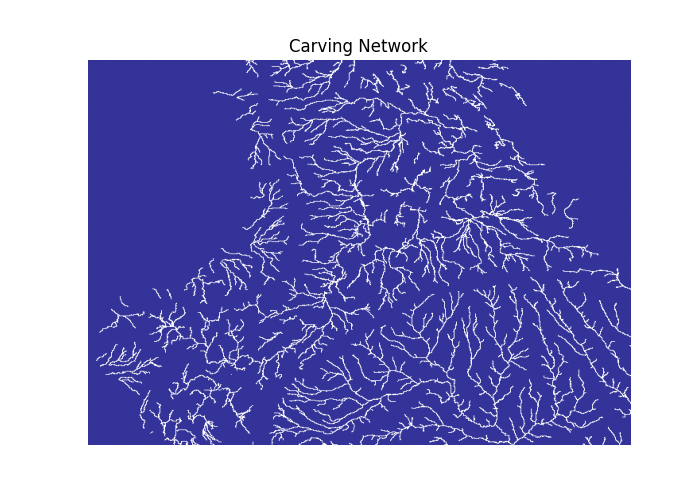

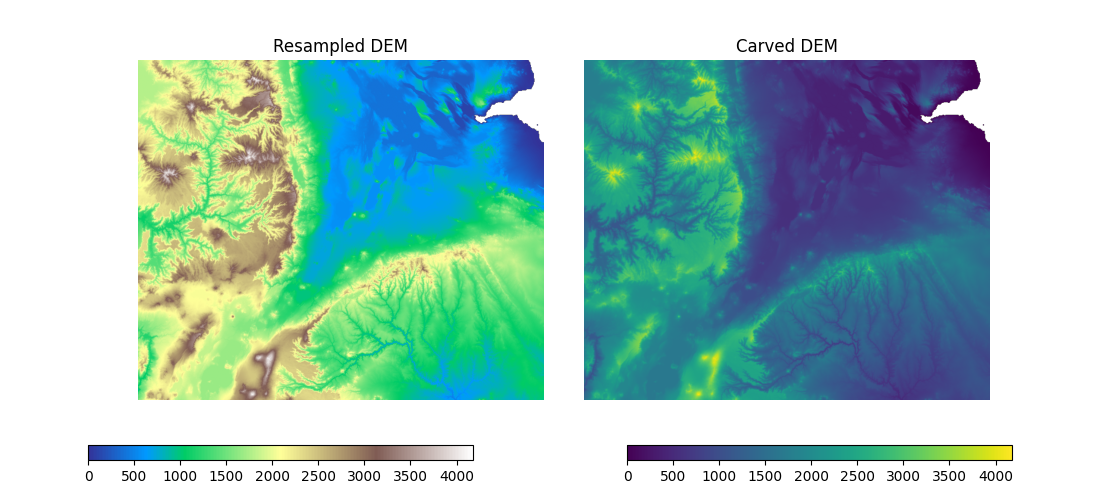

In [8]:
dem_carved = deepcopy(dem_working)
carve_depth = 5 #meters

if config['flags']['carve_dem']:
    if config['data']['stream'] is None:
        raise ValueError("Please provide a stream shapefile for carving in the configuration.")
        
    print(f"Starting DEM carving with {config['data']['stream']} shapefile (this may take a while)...", flush=True)
    
    # Read the stream shapefile
    gdf = gpd.read_file(os.path.join(path_settings['data'], config['data']['stream']))
    shapes = ((geom, 1) for geom in gdf.geometry)
    
    print("Rasterizing shapefile...", flush=True)
    # Rasterize the stream shapefile to create a mask
    stream_mask = features.rasterize(
                shapes,
                out_shape=dem_working.shape,
                transform=tr,
                fill=0,
                dtype='uint8').astype(bool)
                
    # Carve the DEM by subtracting a value along the stream mask
    dem_carved = dem_working - stream_mask * carve_depth
    
    print("\n ✅DEM carving complete.")
    
    # Plot the carving network and compare the original and carved DEMs
    plot_tools.single_plot(stream_mask, "Carving Network", cmap='terrain')
    plot_tools.locked_plot(dem_working, dem_carved, title1="Resampled DEM", title2="Carved DEM")
else:
    print("DEM carving is not active. Skipping this step.")

#### Use Depressions for Endorheic Basins

This cell checks a flag to see if depression points should be used to create holes in the DEM. This is useful for modeling endorheic basins, which are closed drainage basins that retain water and do not drain to an outlet.

In [9]:
dem_depressed = deepcopy(dem_carved)

if config['flags']['use_depressions']:
    if config['data']['depressions'] is None:
        raise ValueError("Please provide a point depression shapefile in the configuration.")
        
    print(f"Creating holes in the DEM with {config['data']['depressions']} shapefile...", flush=True)
    
    # Read the depressions shapefile
    gdf = gpd.read_file(os.path.join(path_settings['data'], config['data']['depressions']))
    shapes = ((geom, 1) for geom in gdf.geometry)
    
    print("Rasterizing shapefile...", flush=True)
    # Rasterize the depression shapefile to create a mask
    depression_mask = features.rasterize(
                shapes,
                out_shape=dem_working.shape,
                transform=tr,
                fill=0,
                dtype='uint8'
            ).astype(bool)
            
    # Set the DEM values at depression points to NaN
    dem_depressed[depression_mask] = np.nan
    
    print("\n✅ Depression operations finished.")
else:
    print("Using depressions is not active. Skipping this step.")

Creating holes in the DEM with iwrm_depressions.shp shapefile...
Rasterizing shapefile...

✅ Depression operations finished.


#### Use Walls

This cell checks a flag to see if walls should be added to the DEM. Walls are used to define boundaries for water flow, which can be useful for modeling specific catchment areas or preventing water from flowing into certain regions.

Walling the DEM with awash_walls.shp shapefile (this may take a while)...
Rasterizing shapefile...
Walling operation finished.


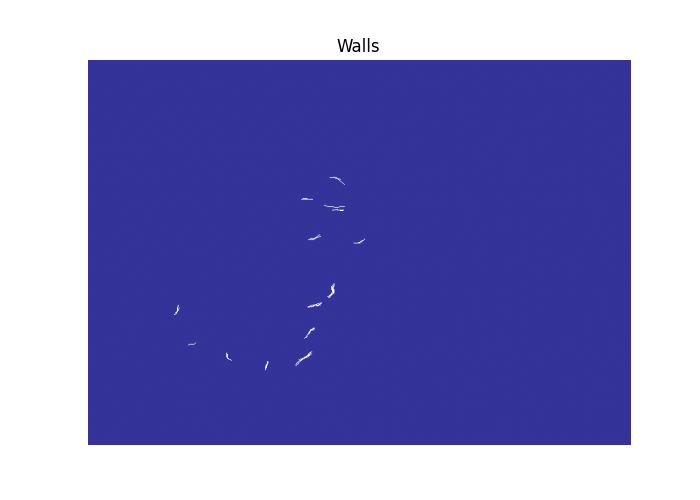

In [10]:
dem_walled = deepcopy(dem_depressed)
wall_heigth = 300 #meters

# Save the DEM before adding walls
dem_file_unwalled = os.path.join(path_settings['ancillary'], "dem_unwalled.tif")
with rio.open(dem_file_unwalled, 'w', **profile) as dst:
    dst.write(dem_walled[np.newaxis, :, :])
    
if config['flags']['use_walls']:
    if config['data']['wall'] is None:
        raise ValueError("Please provide a wall line shapefile in the configuration.")
        
    print(f"Walling the DEM with {config['data']['wall']} shapefile (this may take a while)...", flush=True)
    
    # Read the walls shapefile
    gdf = gpd.read_file(os.path.join(path_settings['data'], config['data']['wall']))
    shapes = ((geom, 1) for geom in gdf.geometry)
    
    print("Rasterizing shapefile...", flush=True)
    # Rasterize the walls shapefile to create a mask
    walls_mask = features.rasterize(
                shapes,
                out_shape=dem_working.shape,
                transform=tr,
                fill=0,
                dtype='uint8'
            ).astype(bool)
            
    # Add a fixed value to the DEM along the wall lines
    dem_walled = dem_walled + walls_mask * wall_heigth
    
    print("Walling operation finished.")
    
    # Plot the walls mask
    plot_tools.single_plot(walls_mask, "Walls", cmap='terrain')
else:
    print("Using walls is not active. Skipping this step.")

#### Write Conditioned DEM

This cell saves the final, conditioned DEM to a GeoTIFF file. This DEM is now ready for use in the hydrological derivatives calculation. The temporary DEM arrays are deleted to free up memory.

In [11]:
dem_file_conditioned = os.path.join(path_settings['ancillary'], "dem_conditioned.tif")
with rio.open(dem_file_conditioned, 'w', **profile) as dst:
    dst.write(dem_walled[np.newaxis, :, :])
    
print(f"Conditioned DEM saved to: {dem_file_conditioned}")

# Clean up temporary DEM arrays from memory
del dem_walled, dem_carved, dem_depressed
print("Temporary DEM arrays deleted.")

Conditioned DEM saved to: /home/continuumuser/workdir/projects/awashOmbole_iwrm/ancillary/dem_conditioned.tif
Temporary DEM arrays deleted.


---

## 🌐 Compute land maps

This section uses GRASS GIS to calculate key hydrological derivatives from the conditioned DE and the other land maps

#### Start GRASS Session

This cell initializes a GRASS GIS session. It sets up the database, location, and mapset. If the mapset doesn't exist, it is created. This session provides the environment for all subsequent GRASS GIS commands.

In [12]:
gisdb = "/home/continuumuser/grassdata"
location = "WGS84"
mapset = f"{config['general']['domain']}_land_data"   # es. "awash_land_data"

location_path = os.path.join(gisdb, location)
perm_path     = os.path.join(location_path, "PERMANENT")
mapset_path   = os.path.join(location_path, mapset)
lockfile      = os.path.join(mapset_path, ".gislock")

# Create location if missing
if not os.path.isdir(perm_path):
    print(f"Creating GRASS LOCATION {location} (EPSG:4326)...")
    subprocess.run(["grass", "--text", "-c", "EPSG:4326", perm_path], check=True)
else:
    print(f"LOCATION {location} already exists.")

# Clean lock files
if os.path.exists(lockfile):
    try:
        os.remove(lockfile)
        print(f"Removed stale lock: {lockfile}")
    except Exception as e:
        print(f"Warning: cannot remove lock {lockfile}: {e}")

if os.path.isdir(mapset_path):
    print(f"Removing existing MAPSET: {mapset_path}")
    shutil.rmtree(mapset_path)

print(f"Creating new MAPSET: {mapset_path}")
os.makedirs(mapset_path, exist_ok=True)

# Coopy required files from PERMANENT
for fname in ("WIND", "DEFAULT_WIND", "PROJ_INFO", "PROJ_UNITS"):
    src = os.path.join(perm_path, fname)
    dst = os.path.join(mapset_path, fname)
    if os.path.exists(src):
        shutil.copy(src, dst)

# Explicitly export GISRC
gisrc_path = f"/tmp/grassrc_{location}_{mapset}"
with open(gisrc_path, "w") as f:
    f.write(f"GISDBASE: {gisdb}\n")
    f.write(f"LOCATION_NAME: {location}\n")
    f.write(f"MAPSET: {mapset}\n")

os.environ["GISRC"] = gisrc_path
print("GISRC set to:", os.environ["GISRC"])

# Register uncovnentional pygrass lirbaries
r.in_gdal        = Module("r.in.gdal")
r.out_gdal       = Module("r.out.gdal")
r.stream_basins  = Module("r.stream.basins")  # NB: il modulo si chiama r.stream.basins
v.in_ogr         = Module("v.in.ogr")

LOCATION WGS84 already exists.
Creating new MAPSET: /home/continuumuser/grassdata/WGS84/awashOmbole_land_data
GISRC set to: /tmp/grassrc_WGS84_awashOmbole_land_data


#### Import DEM into GRASS and Compute Hydroderivatives

This cell imports the preprocessed and conditioned DEMs into the GRASS GIS session. It then uses the `r.watershed` module to compute several hydrological derivatives, including basins, streams, total contributing area (TCA), and drainage direction.

In [13]:
print("Importing DEMs into GRASS GIS and computing hydroderivatives.")
# Import the processed and conditioned DEMs
r.in_gdal(input=dem_file_processed, output="dem_clean", flags='o', overwrite=True, quiet=True)
r.in_gdal(input=dem_file_conditioned, output="dem_conditioned", flags='o', overwrite=True, quiet=True)#g.region(raster="dem_clean", save='extended_region', overwrite=True)

# Set region in grass 8
gs.run_command("g.region", raster="dem_clean", flags="a")
gs.run_command("g.region", save="extended_region", overwrite=True)
print("Settings model region...")
g.region(flags="p")

r.mapcalc(f"dem_clean = if(isnull(dem_conditioned), null(), dem_clean)", overwrite=True)
print("DEMs imported into GRASS GIS.")

# Calculate hydroderivatives using r.watershed
print("Calculating hydroderivatives (basins, streams, TCA, and drainage direction)...")
r.watershed(elevation = "dem_conditioned",
            threshold = int(config["settings"]["soglia_basin_km2"] / (working_res_km ** 2)),
            basin="basin",
            stream="stream",
            accumulation="TCA",
            drainage="pnt_grass",
            flags="sab", overwrite=True, quiet=True)

print("\n✅ Hydroderivatives calculation complete.")

Importing DEMs into GRASS GIS and computing hydroderivatives.
Settings model region...
projection: 3 (Latitude-Longitude)
zone:       0
datum:      wgs84
ellipsoid:  wgs84
north:      12:25:16.500084N
south:      7:17:10.045069N
west:       37:25:10.5E
east:       43:33:43.019747E
nsres:      0:00:32.375578
ewres:      0:00:32.375578
rows:       571
cols:       683
cells:      389993
DEMs imported into GRASS GIS.
Calculating hydroderivatives (basins, streams, TCA, and drainage direction)...

✅ Hydroderivatives calculation complete.


#### Activate mask

This cell checks a flag to see if a mask should be applied to the domain. If enabled, it imports a mask shapefile into GRASS GIS, buffers it, and uses it to define the active computational region. This is useful for focusing the analysis on a specific area of interest.

In [14]:
if config['flags']['use_mask']:
    if config['data']['mask'] is None:
        raise ValueError("Please provide a mask shapefile in the configuration.")
        
    print(f"Applying mask to the domain with {config['data']['mask']} shapefile.", flush=True)
    
    # Remove any existing mask
    try: 
        r.mask(flags='r')
    except: 
        pass
        
    # Import the mask shapefile as a GRASS vector map
    v.in_ogr(input=os.path.join(path_settings['data'], config['data']['mask']), output='mask_v', overwrite=True, quiet=True)
    
    # Buffer the vector mask and set it as the GRASS region
    v.buffer(input='mask_v', output='mask_v_buffer', distance=geo_tools.km2deg(working_res_km) * (3/4), quiet=True, overwrite=True)
    
    # Apply the mask
    r.mask(vector="mask_v", quiet=True)
    gs.run_command("g.region", vector="mask_v_buffer",  align="pnt_grass", flags="a")
    gs.run_command("g.region", save="masked_region", overwrite=True)
    
    print("\n✅ Mask applied successfully.")
else:
    print("Masking is not active. Skipping this step.")

Applying mask to the domain with awashOmbole_mask.shp shapefile.


ERROR: No existing MASK to remove



✅ Mask applied successfully.


#### Write DEM map

This cell generate the map of the:
* **dem** ➡️ the cleaned Digital Elevation Model (m) including only the depressions (if used)

In [15]:
# Define output file paths for the DEM map
dem_map = os.path.join(path_settings["output"], config["general"]["domain"] + ".dem.txt")
temp_map = os.path.join(path_settings["ancillary"], "temp.tiff")

hydroderivatives = {}

print("Exporting DEM map...")

# Export the 'dem_clean' raster from GRASS GIS
r.out_gdal(input='dem_clean', output=temp_map, format='GTiff', overwrite=True, type='Float32', nodata=-9999, flags='fc', quiet=True)

# Convert the GeoTIFF to an ASCII Grid
io_tools.convertAIIGrid(temp_map, dem_map, 'Float32')

# Read the exported DEM into the hydroderivatives dictionary
var = "dem"
with rio.open(dem_map) as src:
    hydroderivatives[var] = src.read(1).astype("float32")
    nod = -9999
    hydroderivatives[var][hydroderivatives[var]==nod] = np.nan
    
print("\n✅ DEM map exported successfully.")

Exporting DEM map...

✅ DEM map exported successfully.


#### Write area and choice maps

This cell exports:
* **area** ➡️ the total contributing area in number of cells
* **choice** ➡️ the rasterized river network maps 

Both are plotted for visual inspection.

Exporting upstream area ... 


         Int32. This can be avoided by using Float64.


Exporting choice map ... 

✅ Upstream area and choice maps exported successfully.


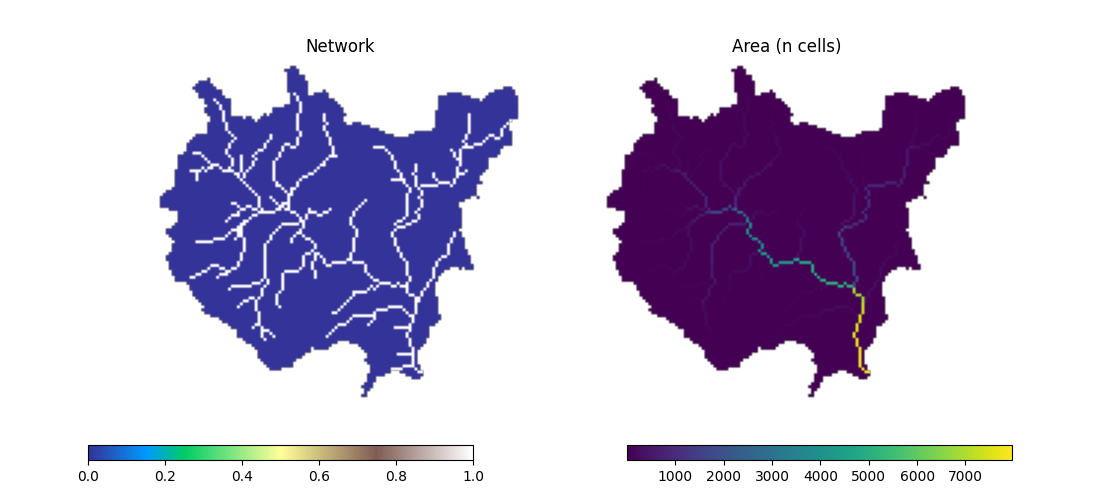

In [16]:
# Define output file paths for area and choice maps
area_map = os.path.join(path_settings["output"], config["general"]["domain"] + ".area.txt")
choice_map = os.path.join(path_settings["output"], config["general"]["domain"] + ".choice.txt")

# Compute and export upstream area (TCA)
print('Exporting upstream area ... ', flush=True)
r.out_gdal(input="TCA", output=temp_map, format='GTiff', overwrite=True, nodata=-9999, type='Int32', flags='fc', 
           quiet=True)
io_tools.convertAIIGrid(temp_map, area_map, 'Int32')

# Compute and export choice map (river network)
print('Exporting choice map ... ', flush=True)
r.mapcalc("choice = if(isnull(stream), 0, 1)", overwrite=True)
r.out_gdal(input='choice', output=temp_map, format='GTiff', overwrite=True, nodata=-9999, type='Int32', flags='fc', 
           quiet=True)
io_tools.convertAIIGrid(temp_map, choice_map, 'Int32')

# Read the exported maps into the hydroderivatives dictionary
for var in ["area", "choice"]:
    path = globals()[f"{var}_map"]
    with rio.open(path) as src:
        hydroderivatives[var] = src.read(1).astype("float32")
        nod = -9999
        hydroderivatives[var][hydroderivatives[var]==nod] = np.nan
print("\n✅ Upstream area and choice maps exported successfully.", flush = True)    
# Plot the maps
plot_tools.locked_plot(hydroderivatives["choice"], hydroderivatives["area"], "Network", "Area (n cells)", 
                       share_palette=False)

#### Write the pnt map

This cell exports the:
* **pnt** ➡️ the drainage direction map, that indicates for each cell in what direction the water is flowing following the D8 convenction and the codification of Continuum. 

It also export the ancillary map:

* **drainage_direction** ➡️ the drainage direction map with QGIS convenction that can be used for basin delineation in QGIS

Starting conversion and export of drainage direction map...


'Convert drainage direction to Continuum standards ... '

Drainage direction map exported successfully.


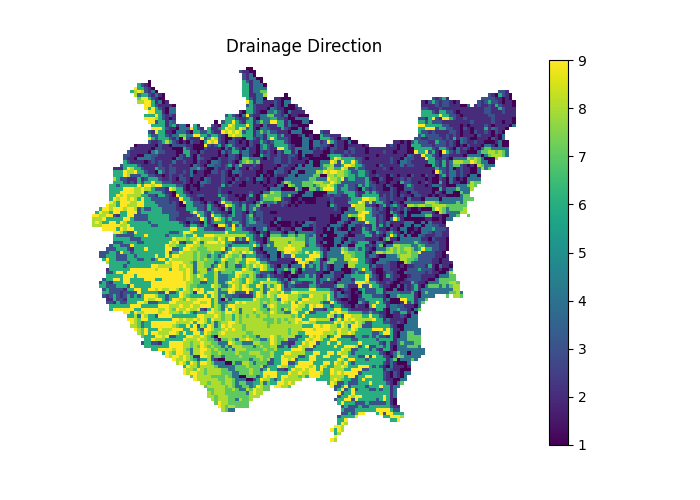

/home/continuumuser/workdir/sources/libraries/plot_tools.py:162: RuntimeWarning: invalid value encountered in cast
  im = ax.imshow(data.astype(int), cmap=cmap, norm=norm)


In [17]:
# Define output file paths for drainage direction maps
pnt_map = os.path.join(path_settings["output"], config["general"]["domain"] + ".pnt.txt")
pntQgis_map = os.path.join(path_settings["ancillary"], "drainage_direction.tif")

print("Starting conversion and export of drainage direction map...")

# Write GRASS to HMC conversion rules file
hmc_tools.writeGrass2HMC(path_settings['ancillary'])

# Convert drainage direction to Continuum standards
display('Convert drainage direction to Continuum standards ... ')
r.reclass(input="pnt_grass",
          output="pnt_HMC", rules=os.path.join(path_settings['ancillary'], "grass2cont.txt"),
          overwrite=True, quiet=True)
          
# Export both the original GRASS and the converted HMC drainage maps
r.out_gdal(input='pnt_grass', output=pntQgis_map, format='GTiff', overwrite=True, type='Int16', flags='fc', quiet=True)
r.out_gdal(input='pnt_HMC', output=temp_map, format='GTiff', overwrite=True, type='Int16', flags='fc', quiet=True)
io_tools.convertAIIGrid(temp_map, pnt_map, 'Int32')

# Read the exported drainage direction map into the hydroderivatives dictionary
var = "pnt"
with rio.open(pnt_map) as src:
    hydroderivatives[var] = src.read(1).astype("float32")
    nod = -9999
    hydroderivatives[var][hydroderivatives[var]==nod] = np.nan
    
print("Drainage direction map exported successfully.")

# Plot the drainage direction map with a D8 legend
plot_tools.single_plot(hydroderivatives["pnt"], "Drainage Direction", cmap='viridis')
ax = plt.gca()
plot_tools.add_d8_legend(ax, hydroderivatives["pnt"], cmap_name="gist_rainbow", ncol=4, pad=0.15)

#### Compute latitude, longitude and areacell maps 

This cell uses GRASS GIS to calculate the Continuum georeferencing static maps, in the details: 
* **latitude** ➡️ Latitude in degrees (WGS84)
* **longitude** ➡️ Longitude in degrees (WGS84)
* **areacell** ➡️ Area of each cell in m^2 

It then exports these maps to GeoTIFF format and converts them to the ASCII Grid format, which is the format suitable for Continuum.

In [18]:
# Define output file paths for lat, lon, and areacell maps
temp_map = os.path.join(path_settings["ancillary"], "temp.tiff")
lat_map = os.path.join(path_settings["output"], config["general"]["domain"] + ".lat.txt")
lon_map = os.path.join(path_settings["output"], config["general"]["domain"] + ".lon.txt")
areacell_map = os.path.join(path_settings["output"], config["general"]["domain"] + ".areacell.txt")

hydroderivatives = {}

# Remove any existing mask
try: 
    r.mask(flags='r')
except: 
    pass
    
# Calculate latitude and longitude maps using GRASS mapcalc
r.mapcalc("lat = y()", overwrite=True, quiet=True)
r.mapcalc("lon = x()", overwrite=True, quiet=True)
r.mapcalc("areacell = area()", overwrite=True, quiet=True)

# Export maps to GeoTIFF and then to ASCII Grid format
print("Exporting latitude, longitude, and areacell maps...")
for var in ["lat", "lon", "areacell"]:
    path = globals()[f"{var}_map"]
    r.out_gdal(input=var, output=temp_map, format='GTiff', overwrite=True, type='Float32', flags='fc', quiet=True)
    io_tools.convertAIIGrid(temp_map, path, 'Float32')
    with rio.open(path) as src:
        hydroderivatives[var] = src.read(1).astype("float32")
        nod = -9999
        hydroderivatives[var][hydroderivatives[var]==nod] = np.nan
        
print("\n✅ Latitude, longitude, and areacell maps are ready.")

Exporting latitude, longitude, and areacell maps...

✅ Latitude, longitude, and areacell maps are ready.


#### Write alpha and beta maps

This final section calculates the maps of the model related to the slope, in particular:
* **alpha** ➡️ represent the downslope index and is used for modelling the behaviour of the water table
* **beta** ➡️  correspond to alpha corrected in the channel cells with a smoothed local slope for modelling the discharge in channels

The calculation is performed by a custom tool and the results are exported as ASCII Grids and then plotted.

Start computing alpha and beta (it might take a while)
1/3 Computing alpha ...
2/3 Computing beta ...
3/3 Writing alpha and beta ...


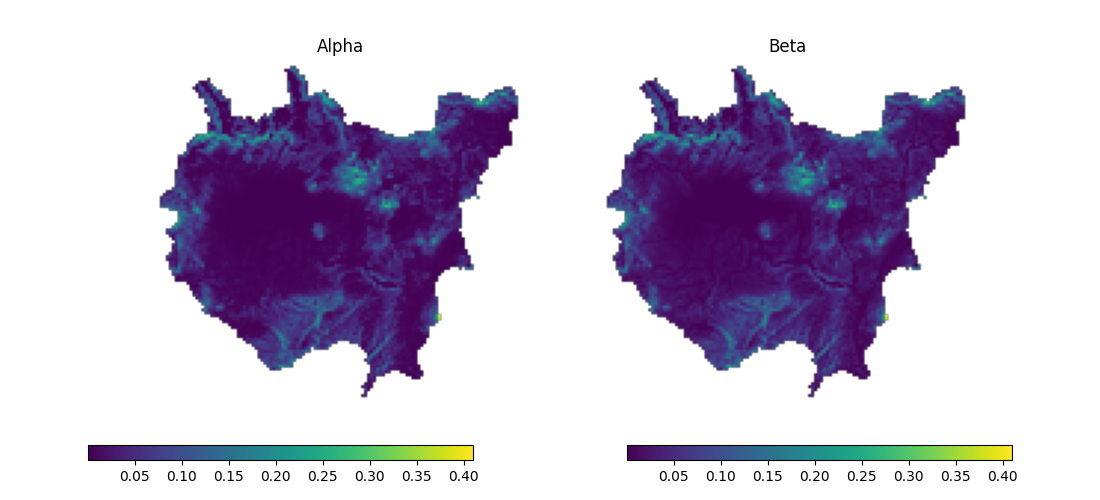


✅ Alpha and beta maps exported successfully.


In [19]:
alpha_map = os.path.join(path_settings["output"], config["general"]["domain"] + ".alpha.txt")
beta_map = os.path.join(path_settings["output"], config["general"]["domain"] + ".beta.txt")
temp_map = os.path.join(path_settings["ancillary"], "temp.tiff")

# Apply the mask
if config['flags']['use_mask']:
    try:
        r.mask(vector="mask_v", quiet=True)
    except:
        pass
    gs.run_command("g.region", region="masked_region")
    
print('Start computing alpha and beta (it might take a while)')
# Alpha & Beta
hmc_tools.makeAlphaBeta(path_settings["output"] + "/", path_settings['ancillary'] + "/", config["general"]["domain"])
for var in ['alpha', 'beta']:
    path = globals()[f"{var}_map"]
    out_fn = os.path.join(path_settings['ancillary'], f"temp_{var}.tif")
    r.in_gdal(input=out_fn, output=var, flags='o', overwrite=True, quiet=True)
    r.out_gdal(input=var, output=temp_map, format='GTiff', overwrite=True, type='Float32', flags='fc', quiet=True)
    io_tools.convertAIIGrid(temp_map, path, 'Float32', precision=6)
    with rio.open(path) as src:
        hydroderivatives[var] = src.read(1).astype("float32")
        nod = -9999
        hydroderivatives[var][hydroderivatives[var]==nod] = np.nan
        
plot_tools.locked_plot(hydroderivatives["alpha"], hydroderivatives["beta"], "Alpha", "Beta", 
                       cmap1 = "viridis", cmap2 = "viridis", share_palette=True)
print("\n✅ Alpha and beta maps exported successfully.")


#### Write ancillary Maps

This section generates additional maps that are useful for understanding the hydrological properties of the domain and for further analysis:
* **mbsn** ➡️ The maps of the macrobasins to be used for identifying useful basins masks
* **upstream_area_km2** ➡️ The maps of the upstream area in km2

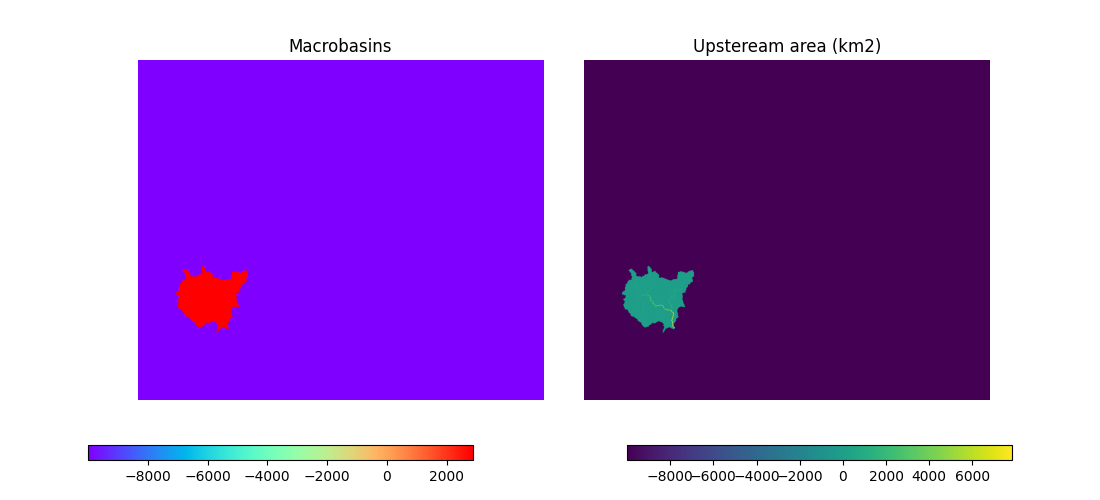

In [20]:
# Macrobasins map
gs.run_command("g.region", region="extended_region")
mbsn_map = os.path.join(path_settings["ancillary"], "mbsn.tif")
areaKm_map = os.path.join(path_settings["ancillary"], "upstream_area_km2.tif")

r.stream_basins(direction=f"pnt_grass",
                stream_rast=f"stream",
                flags='l', basins="mbsn", overwrite=True, quiet=True)

r.out_gdal(input="mbsn", output=mbsn_map, format='GTiff', overwrite=True, type='Int32')
with rio.open(mbsn_map) as src:
    mbsn = src.read(1)

# Cell area and km²
r.mapcalc("areaCellkm = areacell/(10^6)", overwrite=True, quiet=True)
r.accumulate(direction="pnt_grass", format='auto', accumulation="temp.TCA.km2", weight='areaCellkm', overwrite=True, quiet=True)
out_km2 = os.path.join(path_settings['ancillary'], "upstream_area_km2.tif")
r.out_gdal(input="temp.TCA.km2", output=areaKm_map, format='GTiff', overwrite=True, type='Float32')
with rio.open(areaKm_map) as src:
    areaKm = src.read(1)
    
plot_tools.locked_plot(mbsn, areaKm, "Macrobasins", "Upsteream area (km2)", 
                       cmap1 = "rainbow", cmap2 = "viridis", share_palette=False)

#### Clean temporary files

In [21]:
# Clean up temporary files
print("Cleaning up temporary files.")
tmp = Path(path_settings['ancillary'])
for f in tmp.glob("temp*"):
    f.unlink()
print("\n✅ Temporary files cleaned!")

Cleaning up temporary files.

✅ Temporary files cleaned!


## ✅  CONGRATULATION! The domain has been correctely setup!  ✅ 

## 🛑 **WARNING! Be sure the domain is OK before proceed! ** 🛑
Only once the domain is setup it is possible to proceed with the following steps for the definition of the soil and vegetation maps

## 🔧 Preliminary Setup

This section handles the initial configuration, including setting the project file, importing necessary libraries, and preparing the working environment.

#### Import additional libraries

In [22]:
import rasterio as rio
from osgeo import osr

from io_tools import convertAIIGrid

from geo_tools import rasterize_vector_to_model, regrid_to_model
from io_tools import write_tif_from_grid

print("\n✅ Additional libraries loaded!")

# Fill nodata/zero values
def fill(data, invalid=None):
    if invalid is None:
        invalid = (np.isnan(data)) | (data == -9999) | (data == 0)
    valid_mask = ~invalid
    if not np.any(valid_mask):
        return data
    # Get coordinates of valid pixels
    valid_yx = np.argwhere(valid_mask)
    valid_vals = data[valid_mask]
    # Get coordinates of all pixels
    all_yx = np.indices(data.shape).reshape(2, -1).T
    filled_data = data.copy().reshape(-1)
    for idx, (y, x) in enumerate(all_yx):
        if invalid[y, x]:
            # Compute squared distances to valid pixels
            dist2 = (valid_yx[:, 0] - y)**2 + (valid_yx[:, 1] - x)**2
            nearest_idx = np.argmin(dist2)
            filled_data[idx] = valid_vals[nearest_idx]
    return filled_data.reshape(data.shape)
    
# van Genuchten water retention function (1980)
def vg_theta(h_kPa, theta_s, alpha, n, theta_r=0.05, eps=1e-6):
    """
    ----------
    h_kPa : array-like or float
        Soil water pressure head (matric suction) in kPa (negative for suction).
        Common choices:
          - 0 kPa   -> saturation
          - -33 kPa -> field capacity proxy (ct)
          - -1500 kPa -> permanent wilting point
    """
    theta_s = np.asarray(theta_s, dtype=np.float32)
    alpha   = np.asarray(alpha,   dtype=np.float32)
    n       = np.asarray(n,       dtype=np.float32)
    
    m = 1.0 - 1.0 / np.maximum(n, 1.0001)

    h = np.asarray(h_kPa, dtype=np.float32)
    ahn = np.power(np.maximum(alpha * np.abs(h), eps), n)
    theta = theta_r + (theta_s - theta_r) / np.power(1.0 + ahn, m)

    # Optional physical guards (can be relaxed/tuned)
    theta = np.clip(theta, 0.0, np.maximum(theta_s, 0.0))
    return theta.astype(np.float32)

print("\n✅ Additional fucntions imported!")


✅ Additional libraries loaded!

✅ Additional fucntions imported!


#### Local dataset files (edit if needed)

Declare the basemaps to be used for soil and land cover proprieties. They can be modified by the user to use local maps in tif format. If alternative maps are used proper look-up table should be set up.

In [23]:
# Alternative %sand %clay and Land Cover maps can be provided. Land Cover map should be coupled with proper look-up tables for identify soil and vegetation properties
additional_data = {}
additional_data["perc_sand"] = "sources/datasets/Land_Soil/maps/average_sand_ETH_cpr.tif"     # percentage of sand [% * 10] 
additional_data["perc_clay"] = "sources/datasets/Land_Soil/maps/average_clay_ETH_cpr.tif"     # percentage of clay [% * 10]
additional_data["BD"] = "sources/datasets/Land_Soil/maps/BD.tif"            # Bulk density [g cm-3]
additional_data["OC"] = "sources/datasets/Land_Soil/maps/OC.tif"                              # Organic matter content
additional_data["pH"] = "sources/datasets/Land_Soil/maps/pH.tif"                              # pH
additional_data["CEC"] = "sources/datasets/Land_Soil/maps/CEC.tif"                            # Cation-exchange capacity [cmol(+) kg-1]
additional_data["lulc"] = "sources/datasets/Land_Soil/maps/C3S-ESACII-LC-ETH.tif"             # land use land cover
additional_data["lc_to_infilt_table"] = "sources/datasets/Land_Soil/tables/ESA_CCI_to_infilt.csv"     # table to convert land cover to soil properties     
additional_data["lc_to_veg_table"] = "sources/datasets/Land_Soil/tables/ESA_CCI_to_veg.csv"   # table to convert land cover to vegetation

for key in additional_data.keys():
    additional_data[key] = os.path.join(project_root, additional_data[key])
    print("CHECK ",key,":",additional_data[key].replace("/home/continuumuser/workdir/",""), "→", "OK" if os.path.exists(additional_data[key]) else "MISSING")

CHECK  perc_sand : sources/datasets/Land_Soil/maps/average_sand_ETH_cpr.tif → OK
CHECK  perc_clay : sources/datasets/Land_Soil/maps/average_clay_ETH_cpr.tif → OK
CHECK  BD : sources/datasets/Land_Soil/maps/BD.tif → OK
CHECK  OC : sources/datasets/Land_Soil/maps/OC.tif → OK
CHECK  pH : sources/datasets/Land_Soil/maps/pH.tif → OK
CHECK  CEC : sources/datasets/Land_Soil/maps/CEC.tif → OK
CHECK  lulc : sources/datasets/Land_Soil/maps/C3S-ESACII-LC-ETH.tif → OK
CHECK  lc_to_infilt_table : sources/datasets/Land_Soil/tables/ESA_CCI_to_infilt.csv → OK
CHECK  lc_to_veg_table : sources/datasets/Land_Soil/tables/ESA_CCI_to_veg.csv → OK


## 🗺️ Regrid maps on model grid
#### Read reference grid from the model DEM

The DEM maps is used as reference grid for all the other static maps. Regridded maps can be found in the ancillary folder.

In [24]:
def epsg_to_wkt(epsg_code: str) -> str:
    s = osr.SpatialReference()
    s.ImportFromEPSG(int(epsg_code.split(":")[1]))
    return s.ExportToWkt()

with rio.open(dem_map) as src:
    dem = src.read(1)                                
    geotrans = src.transform.to_gdal()               
    wide, high = src.width, src.height
    out_profile = src.profile; out_profile["driver"] = "GTiff"

    # WKT (se manca il CRS, fallback EPSG:4326)
    proj_wkt = src.crs.to_wkt() if src.crs else epsg_to_wkt("EPSG:4326")

    # bbox
    left, bottom, right, top = src.bounds
    lon_min, lon_max, lat_min, lat_max = left, right, bottom, top

model_srs = {
    "proj": proj_wkt,
    "geotrans": geotrans,
    "wide": wide,
    "high": high,
    "bbox": [lon_min, lon_max, lat_min, lat_max],
}
print("Grid:", wide, "x", high)

anc_lc   = os.path.join(path_settings["ancillary"], "LULC_regrid.tif")
anc_soil = os.path.join(path_settings["ancillary"], "average_regrid_{soil_prop}.tif")

regrid_to_model(additional_data["lulc"], anc_lc, model_srs, resample_alg=gdalconst.GRA_Mode, dst_nodata=-9999.0)

print("✅ Regridded land use map saved to: ", os.path.basename(anc_lc))
for soil_prop in ["perc_sand", "perc_clay", "BD", "OC", "pH", "CEC"]:
    regrid_to_model(additional_data[soil_prop], anc_soil.format(soil_prop=soil_prop), model_srs, resample_alg=gdalconst.GRA_Bilinear, dst_nodata=-9999.0)
    print("✅ Regridded " + soil_prop + " map saved to: ", os.path.basename(anc_soil.format(soil_prop=soil_prop)))

Grid: 124 x 115


/app/shybox/.venv/lib/python3.12/site-packages/osgeo/osr.py:410: FutureWarning: Neither osr.UseExceptions() nor osr.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


✅ Regridded land use map saved to:  LULC_regrid.tif
✅ Regridded perc_sand map saved to:  average_regrid_perc_sand.tif
✅ Regridded perc_clay map saved to:  average_regrid_perc_clay.tif
✅ Regridded BD map saved to:  average_regrid_BD.tif
✅ Regridded OC map saved to:  average_regrid_OC.tif
✅ Regridded pH map saved to:  average_regrid_pH.tif
✅ Regridded CEC map saved to:  average_regrid_CEC.tif


#### Read Lake mask (if used)

Read a lake mask on which constant values will be set. The mask can be either shapefile or raster.

In [25]:
if "algorithm" in config and "flags" in config["algorithm"]:
    use_lake_mask = bool(config["algorithm"]["flags"].get("use_lake_mask", False))
else:
    use_lake_mask = bool(config.get("flags", {}).get("use_lake_mask", False))

lake_entry = config.get("data", {}).get("lake_mask", None)
lake_mask = None

if not use_lake_mask or not lake_entry:
    print("Lake mask not used.")
else:
    lake_path = lake_entry if os.path.isabs(lake_entry) else os.path.join(path_settings["data"], lake_entry)
    if not os.path.exists(lake_path):
        print(f"Lake mask not found: {lake_path}")
    else:
        ext = os.path.splitext(lake_path)[1].lower()
        is_vector = ext in [".shp", ".gpkg", ".geojson", ".json"]
        tmp_lake = os.path.join(path_settings["ancillary"], "lake_mask_regrid.tif")
        if is_vector:
            rasterize_vector_to_model(lake_path, tmp_lake, model_srs, burn_value=1, dst_nodata=0, assumed_src_epsg="EPSG:4326")
        else:
            regrid_to_model(lake_path, tmp_lake, model_srs, resample_alg=gdalconst.GRA_NearestNeighbour, dst_nodata=0)
        lake_mask = rio.open(tmp_lake).read(1).astype(int)
        lake_mask = (lake_mask != 0).astype(int)
        print("Lake mask ready:", tmp_lake)

Lake mask ready: /home/continuumuser/workdir/projects/awashOmbole_iwrm/ancillary/lake_mask_regrid.tif


## 🧮 Calculate soil maps

#### Generate soil and runoff parameters
Soil-texture and other soil data are used to compute maps of hydrological parameters using the PTF of Teferi et al. (2018):

* **soil_vmax** ➡️ Maximum soil water storage *(mm)*
* **cn** ➡️ Curve Number (–)

Missing texture data (sand/clay) are filled with default values (40% and 20%, respectively).  
A lake mask is applied to assign constant values (CN = 5, S = 4500 mm) over water bodies.


✅ CN & S exported to: projects/awashOmbole_iwrm/continuum/data_geo/gridded


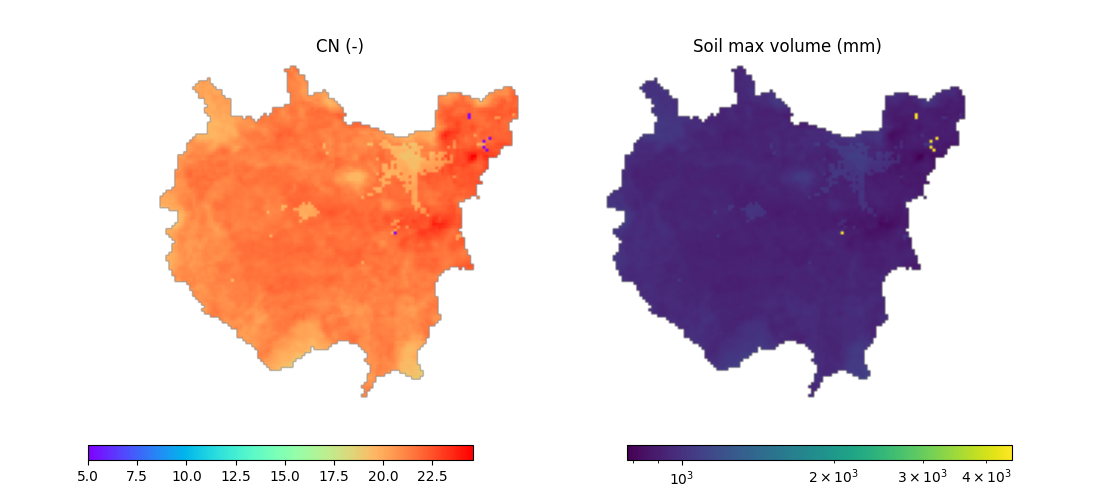

In [26]:
DEFAULT_SAND = 40.0
DEFAULT_CLAY = 20.0
active_soil_depth = 2 #meters
limits_porosity = [0.05, 0.7]

# Sand
anc_sand = anc_soil.format(soil_prop="perc_sand")
sand_map_raw = rio.open(anc_sand).read(1).astype(np.float32)
Sa = np.where((sand_map_raw == -9999) | (sand_map_raw == 0) | np.isnan(sand_map_raw),
                    DEFAULT_SAND*10, sand_map_raw)/10

# Clay
anc_clay = anc_soil.format(soil_prop="perc_clay")
clay_map_raw = rio.open(anc_clay).read(1).astype(np.float32)
Cl = np.where((clay_map_raw == -9999) | (clay_map_raw == 0) | np.isnan(clay_map_raw),
                    DEFAULT_CLAY*10, clay_map_raw)/10

# Silt
Si = 100.0 - Sa - Cl

# Read other soil proprieties
BD = rio.open(anc_soil.format(soil_prop="BD")).read(1).astype(np.float32)
OC = rio.open(anc_soil.format(soil_prop="OC")).read(1).astype(np.float32)
CEC = rio.open(anc_soil.format(soil_prop="CEC")).read(1).astype(np.float32)

# Calculculate saturated water content according to Teferi et al. 
theta_s = (0.976 - 0.497*BD - 0.0043*(1.0/OC) + 3.04*(1.0/Cl) + 0.00059*(CEC*BD) + 0.001*(Cl*BD) - 0.135*(1.0/CEC)).astype(np.float32)
theta_s = np.clip(theta_s, limits_porosity[0], limits_porosity[1])

S = (theta_s * 1000.0 * active_soil_depth).astype(np.float32)
cn_map = 25400.0 / (S + 254.0)

# Apply lake mask to CN and S
S = np.where(lake_mask == 1, 4500, S)
cn_map = np.where(lake_mask == 1, 5, cn_map)

# Temp GeoTIFFs
t_cn = os.path.join(path_settings["ancillary"], "temp_cn.tif")
t_S  = os.path.join(path_settings["ancillary"], "temp_S.tif")
with rio.open(t_cn, 'w', **out_profile) as dst:
    dst.write(cn_map, 1)
with rio.open(t_S, 'w', **out_profile) as dst:
    dst.write(S, 1)

# Export to ASCII grid
convertAIIGrid(t_cn, os.path.join(path_settings["output"], f"{config["general"]["domain"]}.cn.txt"), outType="Int16", precision=0)
convertAIIGrid(t_S, os.path.join(path_settings["output"], f"{config["general"]["domain"]}.soil_vmax.txt"), outType="Float32", precision=2)

print("\n✅ CN & S exported to:", path_settings["output"].replace("/home/continuumuser/workdir/", ""))

#cn_map[cn_map < 0] = np.nan
S[(S < 0) | (dem < -9000)] = np.nan
cn_map[(cn_map < 0) | (dem < -9000)] = np.nan

plot_tools.locked_plot(cn_map, S, "CN (-)", "Soil max volume (mm)", 
                       cmap1 = "rainbow", cmap2 = "viridis", share_palette=False, logscale2=True)

#### Generate field capacity
Teferi et al. (2018) PTFs are used to generathe the parameters of the van Genuchten equation to estimate the:

* **ct** ➡️ Field capacity (θ<sub>fc</sub>, –), volumetric water content at 1/3 bar  

A lake mask is applied to assign constant values (ct = 0.9) over water bodies.

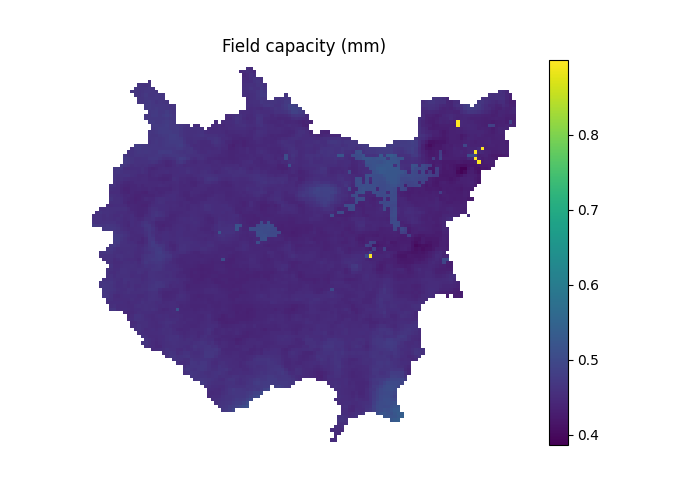

In [27]:
# Set limits for residual water content
min_residual_water = 0.05
max_residual_water = 0.20

# Read other soil proprieties
pH = rio.open(anc_soil.format(soil_prop="pH")).read(1).astype(np.float32)

# Scale parameter
alpha_star = (-3.29 - 0.727*np.log(Sa) - 0.227*(pH*BD) - 0.0153*(CEC*BD) + 0.003*(Sa*Cl) + 0.0008*(Si*Cl)).astype(np.float32)
alpha = np.exp(alpha_star).astype(np.float32)

# Shape parameter
n_star = (-1.46 + 0.011*CEC - 0.019*(Sa*BD) + 5.56e-4*(Sa*Si) - 3.02e-4*(Si*Cl)).astype(np.float32)
n_par = (1.0 + np.exp(n_star)).astype(np.float32)

# Empirical derivation of m
m_par = (1.0 - 1.0/np.maximum(n_par, 1.0001)).astype(np.float32)

# Check residual water content
theta_r = np.full_like(theta_s, min_residual_water, dtype=np.float32)
theta_r = np.clip(theta_r, 0.00, np.minimum(max_residual_water, theta_s - 0.02))

# Calculate ct
ct = vg_theta(-33, theta_s, alpha, n_par)
if 'lake_mask' in globals() and isinstance(lake_mask, np.ndarray) and use_lake_mask:
    ct        = np.where(lake_mask == 1, 0.9, ct)
    
t_ct = os.path.join(path_settings["ancillary"], "temp_ct.tif")
with rio.open(t_ct, 'w', **out_profile) as dst: dst.write(ct.astype(np.float32), 1)
convertAIIGrid(t_ct, os.path.join(path_settings["output"], f"{config["general"]["domain"]}.ct.txt"), outType="Float32", precision=2)

ct[(ct < 0) | (dem < -9000)] = np.nan
plot_tools.single_plot(ct, "Field capacity (mm)", cmap='viridis')

#### Compute soil hydraulic parameters
Pedotransfer functions (PTFs) from **Saxton et al. (1986)** are applied using the sand and clay fraction maps (%). These empirical relationships estimate key soil hydraulic properties required for hydrological modeling. personalised pedotranfer can be used.

* **ct** ➡️ Field capacity (θ<sub>fc</sub>, –), volumetric water content at 1/3 bar  
* **soil_ksat_infilt** ➡️ Saturated hydraulic conductivity for infiltration *(mm h⁻¹)*  
* **soil_ksat_drain** ➡️ Saturated hydraulic conductivity for drainage *(mm h⁻¹)*  

A **lake mask** is optionally applied to override hydraulic values in water bodies, setting:
- **ks_infilt = 100 mm h⁻¹**, **ks_drain = 0.03 mm h⁻¹**, **ct = 0.9**


✅ soil_ksat_infilt, soil_ksat_drain exported to: projects/awashOmbole_iwrm/continuum/data_geo/gridded


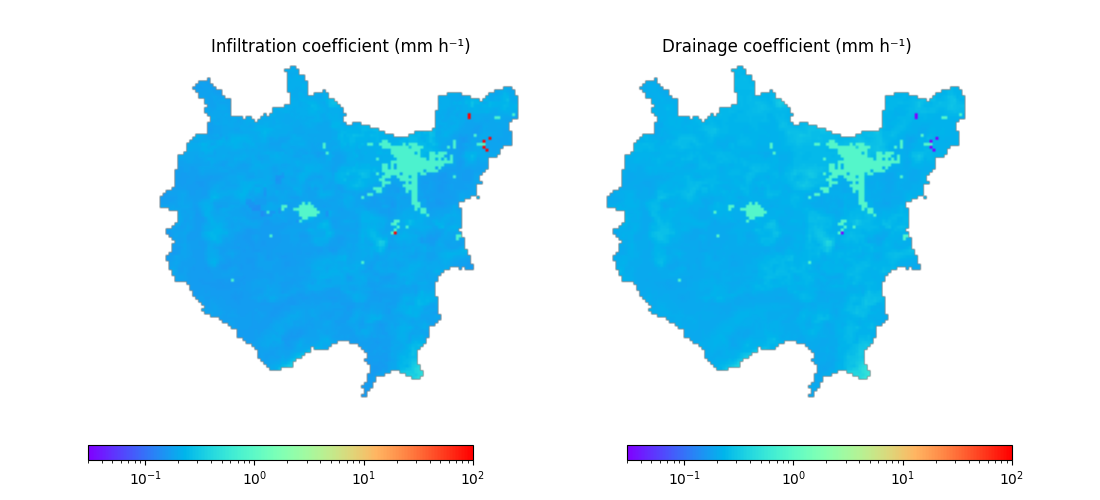

In [28]:
# Saxton et al. (1986) PTFs using sand/clay (%) for coefficient of saturation
sand = Sa.astype(np.float32)
clay = Cl.astype(np.float32)
a = np.exp(-4.396 - 0.0715*clay - 0.000488*(sand**2) - 0.00004285*(sand**2)*clay)
b = -3.14 - 0.00222*(clay**2) - 0.00003484*(sand**2)*clay
ct = (0.33333/a)**(1.0/b)  # field capacity (theta at 1/3 bar)

porosity = 0.332 - 0.0007251*sand + 0.1276*np.log10(np.maximum(clay, 1e-6))
ks_infilt = np.exp((12.012 - 0.0755*sand) + (-3.895 + 0.03671*sand - 0.1103*clay + 0.00087546*(clay**2)) / np.maximum(porosity, 1e-6))
ks_drain = ks_infilt.copy()

# Module infiltration with land cover
lulc_to_infilt = pd.read_csv(additional_data["lc_to_infilt_table"], header=0, usecols=["ID","ksat_mod"], index_col="ID", sep=',')
lulc = rio.open(anc_lc).read(1).astype(np.int32)
ids = lulc_to_infilt.index.to_numpy()
factors = lulc_to_infilt["ksat_mod"].to_numpy()
look = dict(zip(ids, factors))

lut = np.vectorize(lambda x: look.get(int(x), 1))
f_lulc_map = lut(lulc).astype(np.float32)
f_lulc_map[f_lulc_map==0]=1
ks_infilt = (ks_drain * f_lulc_map).astype(np.float32)  

# Apply lake mask overrides if present
if 'lake_mask' in globals() and isinstance(lake_mask, np.ndarray) and use_lake_mask:
    ks_infilt = np.where(lake_mask == 1, 100.0, ks_infilt)
    ks_drain  = np.where(lake_mask == 1, 0.03, ks_drain)

# Save temp tifs
t_k1 = os.path.join(path_settings["ancillary"], "temp_ksat_infilt.tif")
t_k2 = os.path.join(path_settings["ancillary"], "temp_ksat_drain.tif")
with rio.open(t_k1, 'w', **out_profile) as dst: dst.write(ks_infilt.astype(np.float32), 1)
with rio.open(t_k2, 'w', **out_profile) as dst: dst.write(ks_drain.astype(np.float32), 1)

# Export AAIGrid
convertAIIGrid(t_k1, os.path.join(path_settings["output"], f"{config["general"]["domain"]}.soil_ksat_infilt.txt"), outType="Float32", precision=2)
convertAIIGrid(t_k2, os.path.join(path_settings["output"], f"{config["general"]["domain"]}.soil_ksat_drain.txt"), outType="Float32", precision=2)

print("\n✅ soil_ksat_infilt, soil_ksat_drain exported to:", path_settings["output"].replace("/home/continuumuser/workdir/",""))

ks_infilt[(ks_infilt < 0) | (dem < -9000)] = np.nan
ks_drain[(ks_drain < 0) | (dem < -9000)] = np.nan

plot_tools.locked_plot(ks_infilt, ks_drain, "Infiltration coefficient (mm h⁻¹)", "Drainage coefficient (mm h⁻¹)", 
                       cmap1 = "rainbow", cmap2 = "rainbow", share_palette=True, logscale1=True, logscale2=True)

## 🌱 Vegetation Layers (BareSoil, RSmin, Hveg, Gd)

#### Generate vegetation parameters
Look-up tables and land-cover data are combined to produce maps of key vegetation parameters used in hydrological and energy balance modeling:
* **BareSoil** ➡️ 1 if it is a baresoil cell or 0 if not (–)  
* **RSmin** ➡️ Minimum stomatal resistance *(s m⁻¹)*, controls transpiration efficiency  
* **Hveg** ➡️ Vegetation height *(m)*, influences aerodynamic resistance and roughness  
* **Gd** ➡️ VPD sensitivity coefficient *(kPa⁻¹)*, regulates stomatal closure response to vapor pressure deficit

Each parameter is extracted from the land-cover to vegetation look-up table (`lc_to_veg_table`) and mapped onto the study domain using the land-cover raster.  


✅ Vegetation maps exported to: projects/awashOmbole_iwrm/continuum/data_geo/gridded


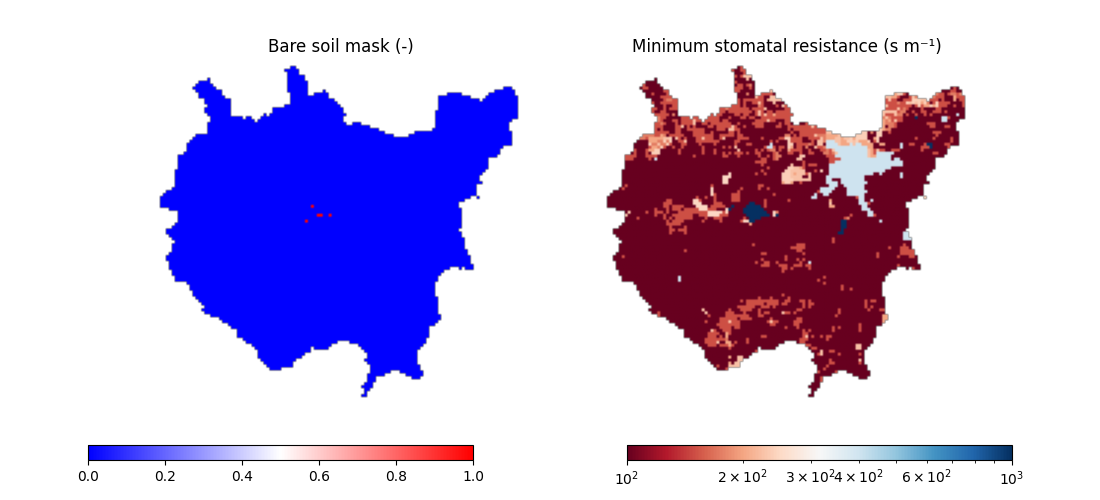

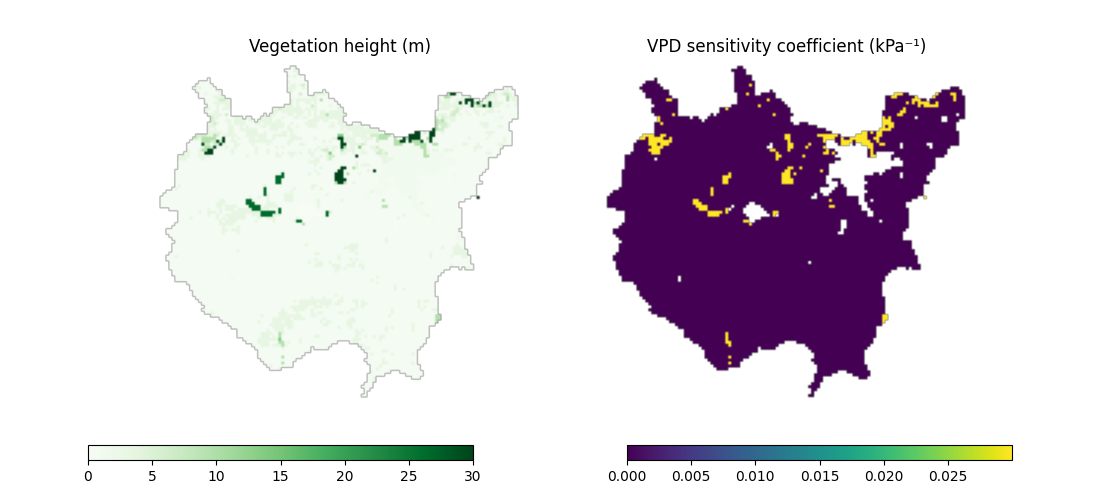

In [29]:
lulc_to_veg = pd.read_csv(additional_data["lc_to_veg_table"], header=0, usecols=["ID","BareSoil","RSmin","Hveg","Gd"], index_col="ID", sep=',')
lulc = rio.open(anc_lc).read(1).astype(np.int32)

veg_vars = {}

for var, outType, precision in [
    ("BareSoil", "Int16",   0),
    ("RSmin",    "Float32", 2),
    ("Hveg",     "Float32", 2),
    ("Gd",       "Float32", 2),
]:
    arr = lulc_to_veg.reindex(lulc.flatten())[var].fillna(-9999).values.reshape(dem.shape).astype(np.float32)
    arr[dem < -9000] = -9999
    t_var = os.path.join(path_settings["ancillary"], f"temp_{var}.tif")
    with rio.open(t_var, 'w', **out_profile) as dst: dst.write(arr, 1)
    convertAIIGrid(t_var, os.path.join(path_settings["output"], f"{config["general"]["domain"]}.{var}.txt"), outType=outType, precision=precision)
    arr[arr <0] = np.nan
    veg_vars[var] = arr.copy()

print("\n✅ Vegetation maps exported to:", path_settings["output"].replace("/home/continuumuser/workdir/",""))

plot_tools.locked_plot(veg_vars["BareSoil"], veg_vars["RSmin"], "Bare soil mask (-)", "Minimum stomatal resistance (s m⁻¹)", 
                       cmap1 = "bwr", cmap2 = "RdBu", share_palette=False, logscale2=True)
plot_tools.locked_plot(veg_vars["Hveg"], veg_vars["Gd"], "Vegetation height (m)", "VPD sensitivity coefficient (kPa⁻¹)", 
                       cmap1 = "Greens", cmap2 = "viridis", share_palette=False)

#### Cleanup

In [30]:
# Remove auxiliary files some GDAL versions might leave
os.system(f'find "{path_settings["output"]}" -maxdepth 1 -type f -name "*.xml" -delete || true')
print("Cleanup done.")

Cleanup done.
